# 3.4 — Partials & the Gradient, at the computer

Do the **pen-and-paper worksheet first**. Here you'll measure partial derivatives by nudging
one input at a time, then draw a loss surface as a contour map and lay the gradient arrows on
top — and watch every arrow point uphill, dead-perpendicular to its contour.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

## 1. Partials by nudging — one input at a time

Same nudge machine as always, but now the function has two inputs, so there are two nudges:
wiggle $x$ with $y$ frozen, then wiggle $y$ with $x$ frozen.

In [2]:
def gradient(f, x, y, h=1e-6):
    df_dx = (f(x + h, y) - f(x, y)) / h    # nudge x only
    df_dy = (f(x, y + h) - f(x, y)) / h    # nudge y only
    return df_dx, df_dy                     # returning two values makes a pair (a 'tuple')

def f(x, y):
    return x**2 + 3*x*y                     # the lesson's worked example

print("∇f at (2, 1) ≈", gradient(f, 2, 1))   # pen-and-paper said (7, 6)

∇f at (2, 1) ≈ (7.000001001955525, 5.999999999062311)


In [3]:
# YOUR TURN — check your worksheet Part B gradients (problems 5–8).
# Problem 5 is set up; add 6, 7 and 8 (you'll need to define each function).

def f5(x, y):
    return x**2 + y**2

print("P5: ∇f(3, 1) ≈", gradient(f5, 3, 1))

# P6: x²y at (2, 5)
# P7: x² - 4x + y² - 2y at (1, 1)
# P8: L(w, b) = (2w + b - 7)² at (1, 1)   — the gradient function doesn't care
#     that the letters are w and b; positions are what matter.

P5: ∇f(3, 1) ≈ (6.000001000927568, 2.0000010003684565)


## 2. The contour map + gradient arrows

$f(x,y) = x^2 + y^2$ is a bowl. Seen from above, its contour lines (equal-height rings) are
circles — worksheet Part D's sketch, drawn by the machine. On top: the gradient measured at a
grid of points, drawn as arrows.

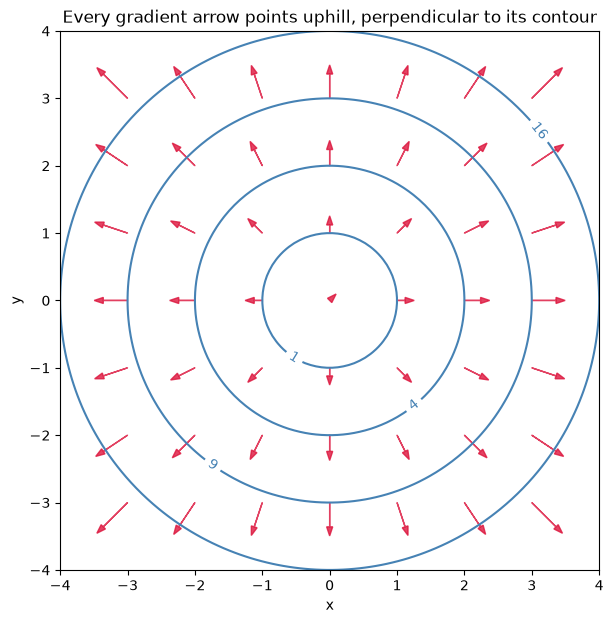

In [4]:
# np.meshgrid turns two 1-D ranges into a full 2-D grid of (x, y) points.
xs = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(xs, xs)
Z = f5(X, Y)                          # heights over the whole grid at once

plt.figure(figsize=(7, 7))
cs = plt.contour(X, Y, Z, levels=[1, 4, 9, 16], colors="steelblue")
plt.clabel(cs)                        # label each ring with its height

# arrows on a coarser grid so they're readable
pts = np.linspace(-3, 3, 7)
for px in pts:
    for py in pts:
        gx, gy = gradient(f5, px, py)
        plt.arrow(px, py, 0.06*gx, 0.06*gy,   # scaled down to fit the picture
                  head_width=0.09, color="crimson", alpha=0.8)

plt.gca().set_aspect("equal")
plt.title("Every gradient arrow points uphill, perpendicular to its contour")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Read the picture: arrows near the rim are long (steep ground, big gradient); near the centre
they shrink to nothing (flat valley floor, $\nabla f \to (0,0)$). Gradient *descent* — next
lesson — will walk exactly **against** these arrows.

## 3. A less polite loss surface

In [5]:
# YOUR TURN — real loss surfaces aren't centred bowls. Map this one:
#     L(w, b) = (w - 2)² + (b + 1)²
# 1. Define it.  2. Where do YOU predict the arrows all point away from?  Write it here: ____
# 3. Adapt the contour+arrows code above (copy, paste, edit) and check your prediction.

def L(w, b):
    return 0   # <- fix me


## 4. 🌀 A glimpse of the deep end: the saddle

Worksheet problem 15 hinted that $\nabla f = (0,0)$ doesn't guarantee a valley floor.
Meet $f(x,y) = x^2 - y^2$: a Pringle. At the origin the gradient is exactly zero —
yet it's downhill in one direction and uphill in another.

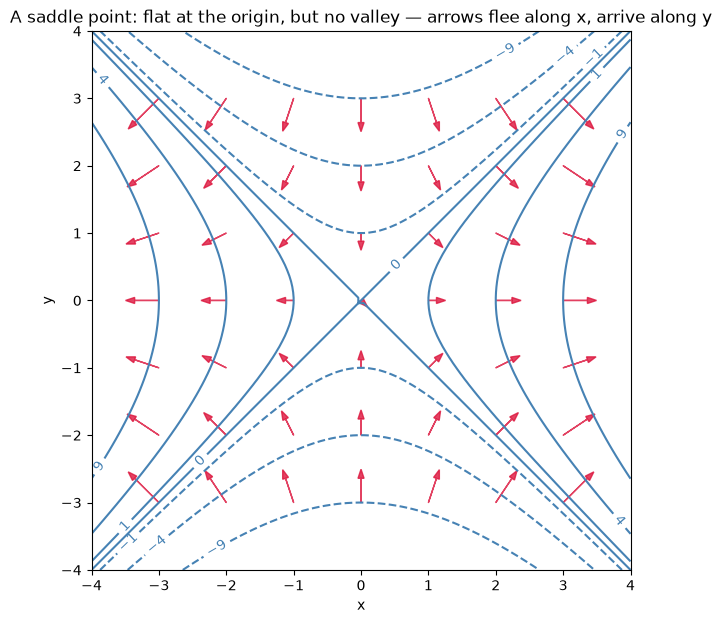

In [6]:
def saddle(x, y):
    return x**2 - y**2

Zs = saddle(X, Y)
plt.figure(figsize=(7, 7))
cs = plt.contour(X, Y, Zs, levels=[-9, -4, -1, 0, 1, 4, 9], colors="steelblue")
plt.clabel(cs)
for px in pts:
    for py in pts:
        gx, gy = gradient(saddle, px, py)
        plt.arrow(px, py, 0.06*gx, 0.06*gy, head_width=0.09, color="crimson", alpha=0.8)
plt.gca().set_aspect("equal")
plt.title("A saddle point: flat at the origin, but no valley — arrows flee along x, arrive along y")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

High-dimensional loss surfaces are riddled with saddles like this — one of the genuinely modern
discoveries about why training big networks works at all. You just drew one from scratch.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 3.5 — gradient descent. The payoff.*